# 02 — Feature Engineering

Inspect the lag / rolling features produced by `windbench.data.make_features` and visualise the train/test split.

In [13]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import seaborn as sns

from windbench.data import load_all_farms, make_features, temporal_split

sns.set_theme(style='whitegrid')
%matplotlib inline

RAW_DIR = '../data/raw'
TARGET_COL = 'energy_w'

In [14]:
farms_raw = load_all_farms(RAW_DIR, target_col=TARGET_COL)

# Feature-engineer one farm
farm_name = list(farms_raw)[0]
df_raw = farms_raw[farm_name]

df_feat = make_features(
    df_raw,
    target_col=TARGET_COL,
    lags=[1, 2, 3, 6, 12, 24],
    rolling_windows=[6, 24],
    add_time_features=True,
)

print(f'Raw shape    : {df_raw.shape}')
print(f'Feature shape: {df_feat.shape}')
print(f'Columns:\n{list(df_feat.columns)}')

Raw shape    : (1732322, 13)
Feature shape: (1732298, 29)
Columns:
['energy_w', 'turbine_id', 'longitude', 'latitude', '2d', '2t', '10u', '10v', '100u', '100v', 'msl', 'tp', 'issue_time', 'energy_w_lag1', 'energy_w_lag2', 'energy_w_lag3', 'energy_w_lag6', 'energy_w_lag12', 'energy_w_lag24', 'energy_w_roll6_mean', 'energy_w_roll6_std', 'energy_w_roll24_mean', 'energy_w_roll24_std', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


In [15]:
X_train, X_val, X_test, y_train, y_val, y_test = temporal_split(
    df_feat, target_col=TARGET_COL, val_frac=0.1, test_frac=0.2
)

print(f'Train: {len(X_train)} rows  ({y_train.index[0]} → {y_train.index[-1]})')
print(f'Val  : {len(X_val)} rows  ({y_val.index[0]} → {y_val.index[-1]})')
print(f'Test : {len(X_test)} rows  ({y_test.index[0]} → {y_test.index[-1]})')

Train: 1212610 rows  (2016-01-21 19:00:00 → 2019-11-15 12:00:00)
Val  : 173229 rows  (2019-11-15 12:00:00 → 2020-05-31 06:00:00)
Test : 346459 rows  (2020-05-31 06:00:00 → 2021-06-30 23:00:00)


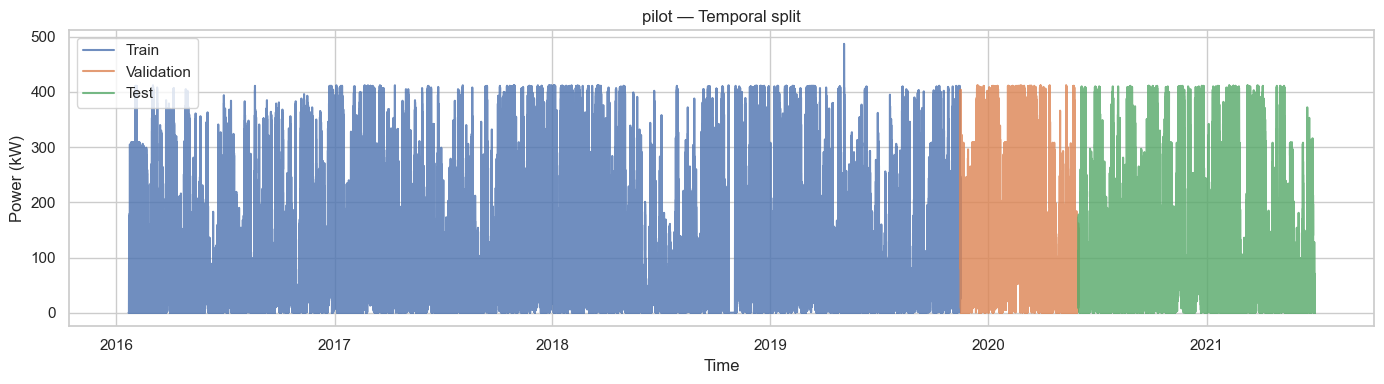

In [16]:
# Visualise the split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_train.index, y_train.values, label='Train', alpha=0.8)
ax.plot(y_val.index, y_val.values, label='Validation', alpha=0.8)
ax.plot(y_test.index, y_test.values, label='Test', alpha=0.8)
ax.set_title(f'{farm_name} — Temporal split')
ax.set_xlabel('Time')
ax.set_ylabel('Power (kW)')
ax.legend()
plt.tight_layout()
plt.show()

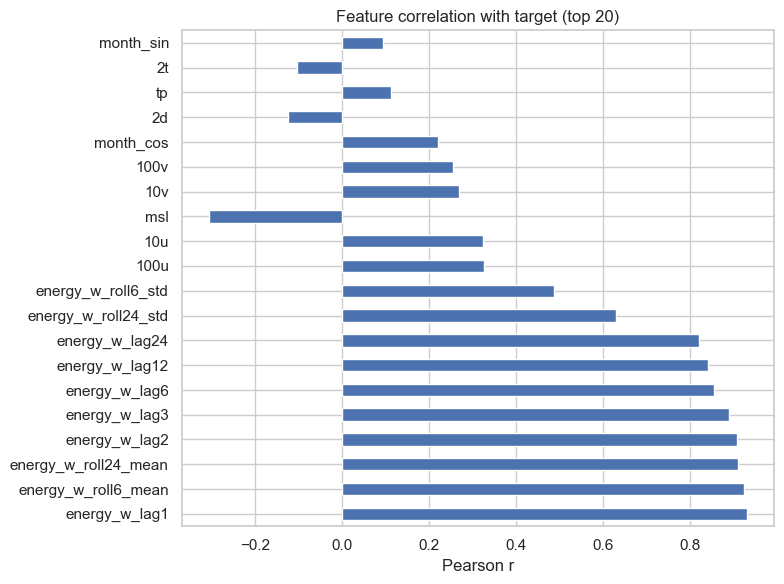

In [17]:
# Feature importance proxy: correlation with target
corr_with_target = df_feat.corr()[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
corr_with_target.head(20).plot(kind='barh', figsize=(8, 6))
plt.title('Feature correlation with target (top 20)')
plt.xlabel('Pearson r')
plt.tight_layout()
plt.show()